# AlphaFold Ensemble Competition Screen

This notebook automates the process of generating AlphaFold predictions for a target protein and two potential ligands to determine which ligand preferentially occupies the user-specified binding site.

Requirements: `colabfold_batch` must be installed and accessible in the system path.

In [1]:
import os
import py3Dmol
import matplotlib.pyplot as plt
from af_competition import run_colabfold, process_ensemble, optimize_threshold  # noqa: F401


## 1. Configuration
Define the sequences, binding site residues, and runtime parameters.

In [2]:
# Sequences (Amino Acids)
TARGET_SEQ = "SQIPASEQETLVRPKPLLLKLLKSVGAQKDTYTMKEVLFYLGQYIMTKRLYDAAQQHIVYCSNDLLGDLFGVPSFSVKEHRKIYTMIYRNLVVVNQQ"
LIGAND_1_SEQ = "ETFSDLWKLLPE"
LIGAND_2_SEQ = "LTFEHYWAQLTS"

# Binding site definition (Residue indices on the Target chain, 1-indexed)
BINDING_SITE_RESIDUES = [42,84]

# Execution parameters
NUM_SEEDS = 20
BASE_OUTPUT_DIRECTORY = "./colabfold_results"
RUN_NAME = "competition"
MIN_PLDDT = 80.0


## 2. Execution
Generate the models using `colabfold_batch`. 
*Note: This step may take significant time depending on sequence length and hardware.*

In [3]:
# Execute ColabFold. Uncomment to run.
ACTUAL_OUTPUT_DIR = run_colabfold(TARGET_SEQ, LIGAND_1_SEQ, LIGAND_2_SEQ, BASE_OUTPUT_DIRECTORY, run_name=RUN_NAME, num_seeds=NUM_SEEDS)
print(f"Models saved to: {ACTUAL_OUTPUT_DIR}")

# If you are skipping execution to analyze a previous run, manually define the directory here:
# ACTUAL_OUTPUT_DIR = "./colabfold_results/competition"
print("ColabFold execution block parsed.")


E0000 00:00:1788528818.730030 2675541 cuda_dnn.cc:8579] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
E0000 00:00:1788528818.736919 2675541 cuda_blas.cc:1407] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered
W0000 00:00:1788528818.754878 2675541 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1788528818.754895 2675541 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1788528818.754897 2675541 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1788528818.754915 2675541 computation_placer.cc:177] computation placer already registered. Please check linka

2026-09-04 14:33:42,061 Running colabfold 1.6.1 (de5ab5f795ed95c70a7a9b6a9dc6bb5625016142)
2026-09-04 14:33:42,424 Running on GPU
2026-09-04 14:33:42,598 Found 5 citations for tools or databases
2026-09-04 14:33:42,599 Query 1/1: complex (length 121)


COMPLETE: 100%|██████████| 450/450 [elapsed: 00:01 remaining: 00:00]


2026-09-04 14:33:46,496 Setting max_seq=508, max_extra_seq=1015
2026-09-04 14:36:01,956 alphafold2_multimer_v3_model_1_seed_25095 recycle=0 pLDDT=81.1 pTM=0.765 ipTM=0.624
2026-09-04 14:37:30,705 alphafold2_multimer_v3_model_1_seed_25095 recycle=1 pLDDT=83.2 pTM=0.79 ipTM=0.725 tol=1.42
2026-09-04 14:37:31,453 alphafold2_multimer_v3_model_1_seed_25095 recycle=2 pLDDT=86.6 pTM=0.822 ipTM=0.774 tol=0.629
2026-09-04 14:37:32,196 alphafold2_multimer_v3_model_1_seed_25095 recycle=3 pLDDT=86.4 pTM=0.822 ipTM=0.776 tol=0.681
2026-09-04 14:37:32,948 alphafold2_multimer_v3_model_1_seed_25095 recycle=4 pLDDT=86.7 pTM=0.819 ipTM=0.771 tol=0.748
2026-09-04 14:37:33,694 alphafold2_multimer_v3_model_1_seed_25095 recycle=5 pLDDT=86.4 pTM=0.825 ipTM=0.778 tol=1.21
2026-09-04 14:37:34,443 alphafold2_multimer_v3_model_1_seed_25095 recycle=6 pLDDT=86.3 pTM=0.82 ipTM=0.774 tol=0.719
2026-09-04 14:37:35,188 alphafold2_multimer_v3_model_1_seed_25095 recycle=7 pLDDT=86.9 pTM=0.828 ipTM=0.779 tol=0.29
2026-09

## 3. Analysis
Parse the resulting PDB files to calculate CA-CA distances between the target binding site and the ligands.

In [4]:
# Process the PDB files (extracting distances and pLDDT)
all_results = process_ensemble(ACTUAL_OUTPUT_DIR, BINDING_SITE_RESIDUES, distance_threshold=0.0)
print(f"Total models parsed: {len(all_results)}")

# Filter by pLDDT
results = [r for r in all_results if r["mean_plddt"] >= MIN_PLDDT]
failed = len(all_results) - len(results)
print(f"Models passing pLDDT threshold ({MIN_PLDDT}): {len(results)}")
print(f"Models failing pLDDT threshold: {failed}")

if len(results) == 0:
    print("No models passed the pLDDT threshold.")
else:
    # Optimize the distance threshold
    optimization_result = optimize_threshold(results, min_thresh=5.0, max_thresh=15.0, step=0.5)
    optimal_threshold = optimization_result['optimal_threshold']
    stats = optimization_result['stats']
    
    print(f"\nOptimal distance threshold found at {optimal_threshold} Å\n")

    def print_files(label, count, files):
        print(f"{label}: {count}")
        if files:
            print("  Files:")
            for f in files:
                print(f"    - {f}")
        else:
            print("  Files: None")
    
    print_files("Ligand 1 exclusively bound", stats['lig1_wins'], stats['lig1_files'])
    print_files("Ligand 2 exclusively bound", stats['lig2_wins'], stats['lig2_files'])
    print_files("Both bound", stats['both_bound'], stats['both_files'])
    print_files("Neither bound", stats['neither_bound'], stats['neither_files'])


Total models parsed: 20
Models passing pLDDT threshold (80.0): 20
Models failing pLDDT threshold: 0

Optimal distance threshold found at 7.0 Å

Ligand 1 exclusively bound: 0
  Files: None
Ligand 2 exclusively bound: 20
  Files:
    - complex_unrelaxed_rank_008_alphafold2_multimer_v3_model_1_seed_25110.pdb
    - complex_unrelaxed_rank_009_alphafold2_multimer_v3_model_1_seed_25098.pdb
    - complex_unrelaxed_rank_004_alphafold2_multimer_v3_model_1_seed_25114.pdb
    - complex_unrelaxed_rank_010_alphafold2_multimer_v3_model_1_seed_25103.pdb
    - complex_unrelaxed_rank_012_alphafold2_multimer_v3_model_1_seed_25109.pdb
    - complex_unrelaxed_rank_016_alphafold2_multimer_v3_model_1_seed_25097.pdb
    - complex_unrelaxed_rank_018_alphafold2_multimer_v3_model_1_seed_25096.pdb
    - complex_unrelaxed_rank_002_alphafold2_multimer_v3_model_1_seed_25111.pdb
    - complex_unrelaxed_rank_011_alphafold2_multimer_v3_model_1_seed_25112.pdb
    - complex_unrelaxed_rank_005_alphafold2_multimer_v3_model

## 4. Visualization

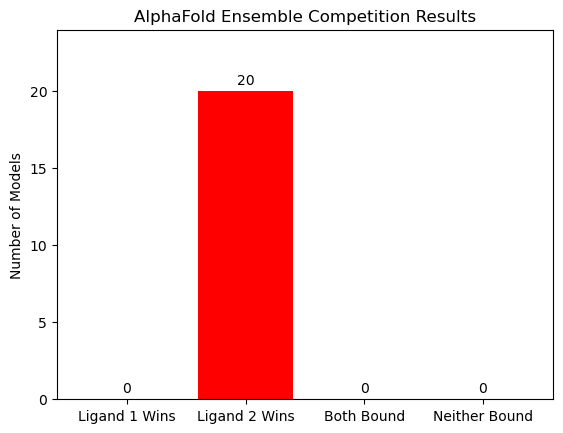

In [5]:
if 'stats' in locals():
    labels = ["Ligand 1 Wins", "Ligand 2 Wins", "Both Bound", "Neither Bound"]
    counts = [stats['lig1_wins'], stats['lig2_wins'], stats['both_bound'], stats['neither_bound']]
    
    fig, ax = plt.subplots()
    bars = ax.bar(labels, counts, color=["blue", "red", "purple", "gray"])
    ax.set_ylabel("Number of Models")
    ax.set_title("AlphaFold Ensemble Competition Results")
    ax.set_ylim(0, max(counts + [1]) * 1.2)
    
    for bar in bars:
        height = bar.get_height()
        ax.annotate(
            f"{height}",
            xy=(bar.get_x() + bar.get_width() / 2, height),
            xytext=(0, 3),  # 3 points vertical offset
            textcoords="offset points",
            ha="center",
            va="bottom",
        )
    
    plt.show()


## 5. Visualization (3D)
Renders the highest confidence model of the winning state.

In [6]:
if 'results' not in locals() or len(results) == 0:
    print("No valid models to visualize.")
else:
    # Determine winning state
    winning_state = "Neither"
    winning_count = -1
    winning_results = []
    
    state_counts = [
        ("Ligand 1", stats['lig1_wins'], stats.get('lig1_results', [])),
        ("Ligand 2", stats['lig2_wins'], stats.get('lig2_results', [])),
        ("Both", stats['both_bound'], stats.get('both_results', []))
    ]
    
    for name, count, res_list in state_counts:
        if count > winning_count:
            winning_count = count
            winning_state = name
            winning_results = res_list
    
    if winning_count == 0 or not winning_results:
        print("No dominant binding state found among valid models.")
    else:
        # Find model with highest pLDDT
        best_model = max(winning_results, key=lambda x: x["mean_plddt"])
        best_pdb = os.path.join(ACTUAL_OUTPUT_DIR, best_model["pdb_file"])
        
        print(f"Visualizing Winning State: {winning_state} Bound")
        print(f"Best Model: {best_model['pdb_file']} (pLDDT: {best_model['mean_plddt']:.1f})")
        print("Target (Chain A) = Grey | Ligand 1 (Chain B) = Blue | Ligand 2 (Chain C) = Red")
        
        with open(best_pdb, 'r') as f:
            pdb_data = f.read()
            
        view = py3Dmol.view(width=800, height=600)
        view.addModel(pdb_data, 'pdb')
        
        # Target (Chain A)
        view.setStyle({'chain': 'A'}, {'cartoon': {'color': 'lightgray'}})
        # Ligand 1 (Chain B)
        view.setStyle({'chain': 'B'}, {'cartoon': {'color': 'blue'}, 'stick': {'color': 'blue'}})
        # Ligand 2 (Chain C)
        view.setStyle({'chain': 'C'}, {'cartoon': {'color': 'red'}, 'stick': {'color': 'red'}})
        
        view.zoomTo()
        view.show()


Visualizing Winning State: Ligand 2 Bound
Best Model: complex_unrelaxed_rank_001_alphafold2_multimer_v3_model_1_seed_25104.pdb (pLDDT: 88.2)
Target (Chain A) = Grey | Ligand 1 (Chain B) = Blue | Ligand 2 (Chain C) = Red


3Dmol.js failed to load for some reason. Please check your browser console for error messages.